In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from src.adasecant import Adasecant

In [2]:
torch.manual_seed(0)
X = torch.linspace(-3, 3, 100).unsqueeze(1)
y = 2 * X + 1 + torch.randn_like(X)

model = nn.Linear(1, 1)
optimizer = Adasecant(model.parameters())
criterion = nn.MSELoss()

losses = []
for epoch in range(100):
    optimizer.zero_grad()
    loss = criterion(model(X), y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch = {epoch}, mse = {loss}")

with torch.no_grad():
    y_pred = model(X)

w = model.weight.item()
b = model.bias.item()
print(f"Learned: y = {w:.3f}x + {b:.3f}  (true: y = 2x + 1)")

Epoch = 0, mse = 17.506412506103516
Epoch = 10, mse = 1.0801386833190918
Epoch = 20, mse = 1.061316728591919
Epoch = 30, mse = 1.0575889348983765
Epoch = 40, mse = 1.0559192895889282
Epoch = 50, mse = 1.0550390481948853
Epoch = 60, mse = 1.055001974105835
Epoch = 70, mse = 1.0532716512680054
Epoch = 80, mse = 1.053173542022705
Epoch = 90, mse = 1.0533843040466309
Learned: y = 1.969x + 1.042  (true: y = 2x + 1)


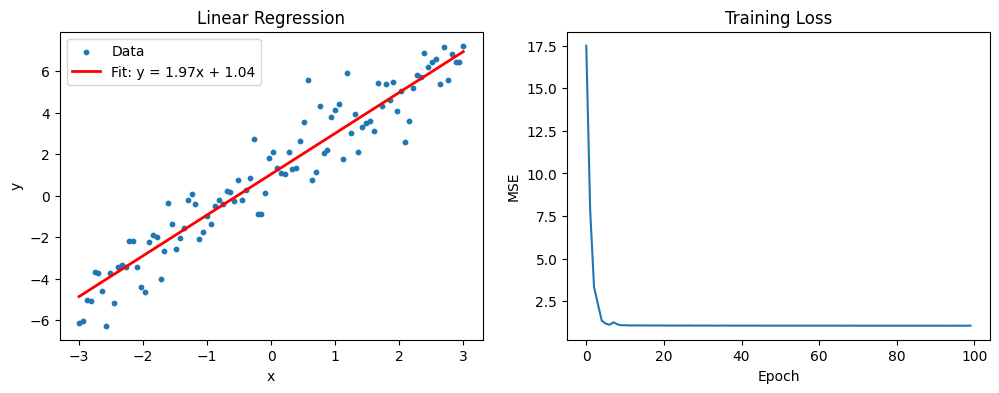

In [3]:
with torch.no_grad():
    y_pred = model(X)

w = model.weight.item()
b = model.bias.item()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X.numpy(), y.numpy(), s=10, label="Data")
ax1.plot(X.numpy(), y_pred.numpy(), color="red", linewidth=2, label=f"Fit: y = {w:.2f}x + {b:.2f}")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title("Linear Regression")
ax1.legend()

ax2.plot(losses)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MSE")
ax2.set_title("Training Loss")

# plt.tight_layout()
plt.show()